# Кластеризация музыки

Будем работать с данными о том, каких исполнителей слушают пользователи музыкального сервиса.

Каждая строка таблицы - информация об одном пользователе. Каждый столбец - это исполнитель (The Beatles, Radiohead, etc.)

Для каждой пары (пользователь, исполнитель) в таблице стоит число - доля прослушивания этого исполнителя этим пользователем.


In [41]:
import pandas as pd
ratings = pd.read_excel("https://github.com/evgpat/edu_stepik_rec_sys/blob/main/datasets/sample_matrix.xlsx?raw=true", engine='openpyxl')
ratings.head()

,user,the beatles,radiohead,deathcab for cutie,coldplay,modest mouse,sufjan stevens,dylan. bob,red hot clili peppers,pink fluid,...,municipal waste,townes van zandt,curtis mayfield,jewel,lamb,michal w. smith,群星,agalloch,meshuggah,yellowcard
0,0,NaN,0.020417,NaN,NaN,NaN,NaN,NaN,0.030496,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,NaN,0.184962,0.024561,NaN,NaN,0.136341,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,NaN,NaN,0.028635,NaN,NaN,NaN,0.024559,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,0.043529,0.086281,0.034590,0.016712,0.015935,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Будем строить кластеризацию исполнителей: если двух исполнителей слушало много людей примерно одинаковую долю своего времени (то есть векторы близки в пространстве), то, возможно исполнители похожи. Эта информация может быть полезна при построении рекомендательных систем.

## Задание 1 (0.5 балла) Подготовка

Транспонируем матрицу ratings, чтобы по строкам стояли исполнители.

In [42]:
ratings = ratings.T
ratings.head()

,0,1,2,3,4,5,6,7,8,9,...,4990,4991,4992,4993,4994,4995,4996,4997,4998,4999
user,0.000000,1.000000,2.000000,3.0,4.000000,5.000000,6.0,7.0,8.000000,9.000000,...,4990.000000,4991.0,4992.000000,4993.000000,4994.000000,4995.000000,4996.0,4997.000000,4998.0,4999.000000
the beatles,NaN,NaN,NaN,NaN,0.043529,NaN,NaN,NaN,0.093398,0.017621,...,NaN,NaN,0.121169,0.038168,0.007939,0.017884,NaN,0.076923,NaN,NaN
radiohead,0.020417,0.184962,NaN,NaN,0.086281,0.006322,NaN,NaN,NaN,0.019156,...,0.017735,NaN,NaN,NaN,0.011187,NaN,NaN,NaN,NaN,NaN
deathcab for cutie,NaN,0.024561,0.028635,NaN,0.034590,NaN,NaN,NaN,NaN,0.013349,...,0.121344,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.027893
coldplay,NaN,NaN,NaN,NaN,0.016712,NaN,NaN,NaN,NaN,NaN,...,0.217175,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Выкиньте строку под названием `user`.

In [43]:
ratings.drop('user', inplace=True, axis=0)
ratings.head()

,0,1,2,3,4,5,6,7,8,9,...,4990,4991,4992,4993,4994,4995,4996,4997,4998,4999
the beatles,NaN,NaN,NaN,NaN,0.043529,NaN,NaN,NaN,0.093398,0.017621,...,NaN,NaN,0.121169,0.038168,0.007939,0.017884,NaN,0.076923,NaN,NaN
radiohead,0.020417,0.184962,NaN,NaN,0.086281,0.006322,NaN,NaN,NaN,0.019156,...,0.017735,NaN,NaN,NaN,0.011187,NaN,NaN,NaN,NaN,NaN
deathcab for cutie,NaN,0.024561,0.028635,NaN,0.034590,NaN,NaN,NaN,NaN,0.013349,...,0.121344,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.027893
coldplay,NaN,NaN,NaN,NaN,0.016712,NaN,NaN,NaN,NaN,NaN,...,0.217175,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
modest mouse,NaN,NaN,NaN,NaN,0.015935,NaN,NaN,NaN,NaN,0.030437,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [44]:
ratings.shape

(1000, 5000)

В таблице много пропусков, так как пользователи слушают не всех-всех исполнителей, чья музыка представлена в сервисе, а некоторое подмножество (обычно около 30 исполнителей)


Доля исполнителя в музыке, прослушанной  пользователем, равна 0, если пользователь никогда не слушал музыку данного музыканта, поэтому заполните пропуски нулями.



In [45]:
ratings.fillna(0, inplace=True)
ratings.head()

,0,1,2,3,4,5,6,7,8,9,...,4990,4991,4992,4993,4994,4995,4996,4997,4998,4999
the beatles,0.000000,0.000000,0.000000,0.0,0.043529,0.000000,0.0,0.0,0.093398,0.017621,...,0.000000,0.0,0.121169,0.038168,0.007939,0.017884,0.0,0.076923,0.0,0.000000
radiohead,0.020417,0.184962,0.000000,0.0,0.086281,0.006322,0.0,0.0,0.000000,0.019156,...,0.017735,0.0,0.000000,0.000000,0.011187,0.000000,0.0,0.000000,0.0,0.000000
deathcab for cutie,0.000000,0.024561,0.028635,0.0,0.034590,0.000000,0.0,0.0,0.000000,0.013349,...,0.121344,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.027893
coldplay,0.000000,0.000000,0.000000,0.0,0.016712,0.000000,0.0,0.0,0.000000,0.000000,...,0.217175,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000
modest mouse,0.000000,0.000000,0.000000,0.0,0.015935,0.000000,0.0,0.0,0.000000,0.030437,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000


## Задание 2 (0.5 балла) Первая кластеризация

Примените KMeans с 5ю кластерами, сохраните полученные лейблы

In [46]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42)

cluster_labels = kmeans.fit_predict(ratings)

ratings["Cluster"] = cluster_labels

print(ratings.head())

                           0         1         2    3         4         5  \
the beatles         0.000000  0.000000  0.000000  0.0  0.043529  0.000000   
radiohead           0.020417  0.184962  0.000000  0.0  0.086281  0.006322   
deathcab for cutie  0.000000  0.024561  0.028635  0.0  0.034590  0.000000   
coldplay            0.000000  0.000000  0.000000  0.0  0.016712  0.000000   
modest mouse        0.000000  0.000000  0.000000  0.0  0.015935  0.000000   

                      6    7         8         9  ...  4991      4992  \
the beatles         0.0  0.0  0.093398  0.017621  ...   0.0  0.121169   
radiohead           0.0  0.0  0.000000  0.019156  ...   0.0  0.000000   
deathcab for cutie  0.0  0.0  0.000000  0.013349  ...   0.0  0.000000   
coldplay            0.0  0.0  0.000000  0.000000  ...   0.0  0.000000   
modest mouse        0.0  0.0  0.000000  0.030437  ...   0.0  0.000000   

                        4993      4994      4995  4996      4997  4998  \
the beatles         0.03

Выведите размеры кластеров. Полезной ли получилась кластеризация? Почему KMeans может выдать такой результат?

In [47]:
cluster_counts = ratings["Cluster"].value_counts().sort_index()

print(cluster_counts)

Cluster
0    115
1      1
2      1
3    882
4      1
Name: count, dtype: int64


Можно предположить что есть три суперпопулярные группы которые слушают почти все. Например 90, 80 и 70% слушателей. Потом есть кластер групп средней популярности, допустим их слушают 20% пользователей. И наконец самый большой кластер групп, популярных только среди ценителей, например 5%.

## Задание 3 (0.5 балла) Объяснение результатов

При кластеризации получилось $\geq 1$ кластера размера 1. Выведите исполнителей, которые составляют такие кластеры. Среди них должна быть группа The Beatles.

In [48]:
small_clusters = ratings["Cluster"].value_counts()[lambda x: x == 1].index

for cluster in small_clusters:
    artists_in_cluster = ratings[ratings['Cluster'] == cluster].index
    print(f"Кластер {cluster} содержит исполнителей:")
    print(artists_in_cluster.values)

Кластер 4 содержит исполнителей:
['the beatles']
Кластер 2 содержит исполнителей:
['niИ']
Кластер 1 содержит исполнителей:
['日dir en grey']


Изучите данные, почему именно The Beatles выделяется?

Подсказка: посмотрите на долю пользователей, которые слушают каждого исполнителя, среднюю долю прослушивания.

In [49]:
listening_beatles = (ratings.loc['the beatles'].iloc[:-1] > 0).mean()*100
average_beatles = ratings.loc['the beatles'].iloc[:-1].mean()

print(f"\nДоля пользователей, которые слушают The Beatles: {listening_beatles:.2f}%")
print(f"Средняя доля прослушивания The Beatles: {average_beatles:.4f}")


listening_ni = (ratings.loc['niИ'].iloc[:-1] > 0).mean()*100
average_ni = ratings.loc['niИ'].iloc[:-1].mean()

print(f"\nДоля пользователей, которые слушают niИ: {listening_ni:.2f}%")
print(f"Средняя доля прослушивания niИ: {average_ni:.4f}")

listening_dir = (ratings.loc['日dir en grey'].iloc[:-1] > 0).mean()*100
average_dir = ratings.loc['日dir en grey'].iloc[:-1].mean()

print(f"\nДоля пользователей, которые слушают 日dir en grey: {listening_dir:.2f}%")
print(f"Средняя доля прослушивания 日dir en grey: {average_dir:.4f}")


Доля пользователей, которые слушают The Beatles: 33.42%
Средняя доля прослушивания The Beatles: 0.0184

Доля пользователей, которые слушают niИ: 11.82%
Средняя доля прослушивания niИ: 0.0065

Доля пользователей, которые слушают 日dir en grey: 1.02%
Средняя доля прослушивания 日dir en grey: 0.0017


In [50]:
def calculate_artist_stats(row):
    return pd.Series({
        'Users_Listening': (row > 0).mean(),
        'Average_Share': row.mean()
    })

artist_stats = ratings.iloc[:, :-1].apply(calculate_artist_stats, axis=1)

print("\nСтатистика по всем исполнителям:")
print(artist_stats.sort_values(by=['Users_Listening', 'Average_Share'], ascending=False))


Статистика по всем исполнителям:
                    Users_Listening  Average_Share
the beatles                  0.3342       0.018369
radiohead                    0.2778       0.011851
deathcab for cutie           0.1862       0.006543
coldplay                     0.1682       0.006030
modest mouse                 0.1628       0.005876
...                             ...            ...
thomas newman                0.0094       0.000425
jewel                        0.0094       0.000347
curtis mayfield              0.0094       0.000341
yellowcard                   0.0094       0.000320
lamb                         0.0094       0.000295

[1000 rows x 2 columns]


The Beatles наиболее популярна из всех, ее слушает наибольшее число пользователей и у нее наивысшая доля прослушивания. При этом чем выбиваются две другие группы сходу непонятно. Хотя можно заметить, что у них гораздо выше средняя доля прослушиваний, чем у других групп со сходным общим числом слушателей. Видимо у этих двух групп наиболее преданные фанаты

## Задание 4 (0.5 балла) Улучшение кластеризации

Попытаемся избавиться от этой проблемы: нормализуйте данные при помощи `normalize`.

In [51]:
from sklearn.preprocessing import normalize

ratings.drop('Cluster', inplace=True, axis=1)
print(ratings.shape)

(1000, 5000)


In [52]:
ratings = pd.DataFrame(normalize(ratings, norm='l2', axis=1), index=ratings.index, columns=ratings.columns)
print(ratings.head())

                        0         1         2     3         4         5     \
the beatles         0.000000  0.000000  0.000000   0.0  0.012054  0.000000   
radiohead           0.009348  0.084688  0.000000   0.0  0.039505  0.002894   
deathcab for cutie  0.000000  0.017278  0.020144   0.0  0.024333  0.000000   
coldplay            0.000000  0.000000  0.000000   0.0  0.011129  0.000000   
modest mouse        0.000000  0.000000  0.000000   0.0  0.010260  0.000000   

                    6     7         8         9     ...      4990  4991  \
the beatles          0.0   0.0  0.025864  0.004880  ...  0.000000   0.0   
radiohead            0.0   0.0  0.000000  0.008771  ...  0.008120   0.0   
deathcab for cutie   0.0   0.0  0.000000  0.009391  ...  0.085361   0.0   
coldplay             0.0   0.0  0.000000  0.000000  ...  0.144628   0.0   
modest mouse         0.0   0.0  0.000000  0.019597  ...  0.000000   0.0   

                        4992      4993      4994      4995  4996      4997  \
th

Примените KMeans с 5ю кластерами на преобразованной матрице, посмотрите на их размеры. Стало ли лучше? Может ли кластеризация быть полезной теперь?

In [53]:
kmeans = KMeans(n_clusters=5, random_state=42)
cluster_labels = kmeans.fit_predict(ratings)
ratings['Cluster'] = cluster_labels

cluster_sizes = ratings['Cluster'].value_counts().sort_index()

print(f"Размеры классов после нормализации:")
print(cluster_sizes)

Размеры классов после нормализации:
Cluster
0     79
1    162
2    133
3    140
4    486
Name: count, dtype: int64


Кластеры действительно стали лучше, гораздо сбалансированнее. Хотя 4 кластер подозрительно большой

## Задание 5 (1 балл) Центроиды

Выведите для каждого кластера названия топ-10 исполнителей, ближайших к центроиду по косинусной мере. Проинтерпретируйте результат. Что можно сказать о смысле кластеров?

In [54]:
from scipy.spatial.distance import cosine


centroids = kmeans.cluster_centers_

top_cluster_artists = {}


for cluster_id in range(len(centroids)):
  centroid = centroids[cluster_id]
  distances = ratings.iloc[:, :-1].apply(lambda row: cosine(centroid, row), axis=1)
  top_artists = distances.nsmallest(10).index.tolist()
  top_cluster_artists[cluster_id] = top_artists

for cluster_id, top_artists in top_cluster_artists.items():
  print(f"Кластер: {cluster_id}")
  print(top_artists)
  print()

Кластер: 0
['nas', 'jay-z', 'kanye west', 'lupe the gorilla', 'a tribe called quest', "the roots featuring d'angelo", 'gangstarr', 'little brother', "lil' wayne", 'murs and 9th wonder']

Кластер: 1
['fall out boy', 'the all-americian rejects', 'paramore', 'kelly clarkson', 'john mayer', 'the fray', 'maroon5', 'dashboard confesssional', 'somethings corporate', 'coldplay']

Кластер: 2
['brand new', 'blink-182', 'alkaline trio', 'against me!', 'underoath', 'descendents', 'new found glory', 'less than jake', 'thrice', 'chiodos']

Кластер: 3
['the beatles', 'the rolling stones', 'dylan. bob', 'who', 'led zeppelin.', 'miles davis.', 'simon and garfunkel', 'young, neil', 'pink fluid', 'velvet underground']

Кластер: 4
['radiohead', 'the arcade fire', 'the shins', 'sufjan stevens', 'belle and sebastian', 'broken social scene', 'the pixies', 'animal collective', 'modest mouse', 'spoon']



Теперь музыка четко разбита по жанрам. В первом кластере очевидны рэперы, во втором поп-рок, в третьем поп-панк, далее идет рок и альтернатива.

## Задание 6 (1 балл) Визуализация

Хотелось бы как-то визуализировать полученную кластеризацию. Постройте точечные графики `plt.scatter` для нескольких пар признаков исполнителей, покрасив точки в цвета кластеров. Почему визуализации получились такими? Хорошо ли они отражают разделение на кластеры? Почему?

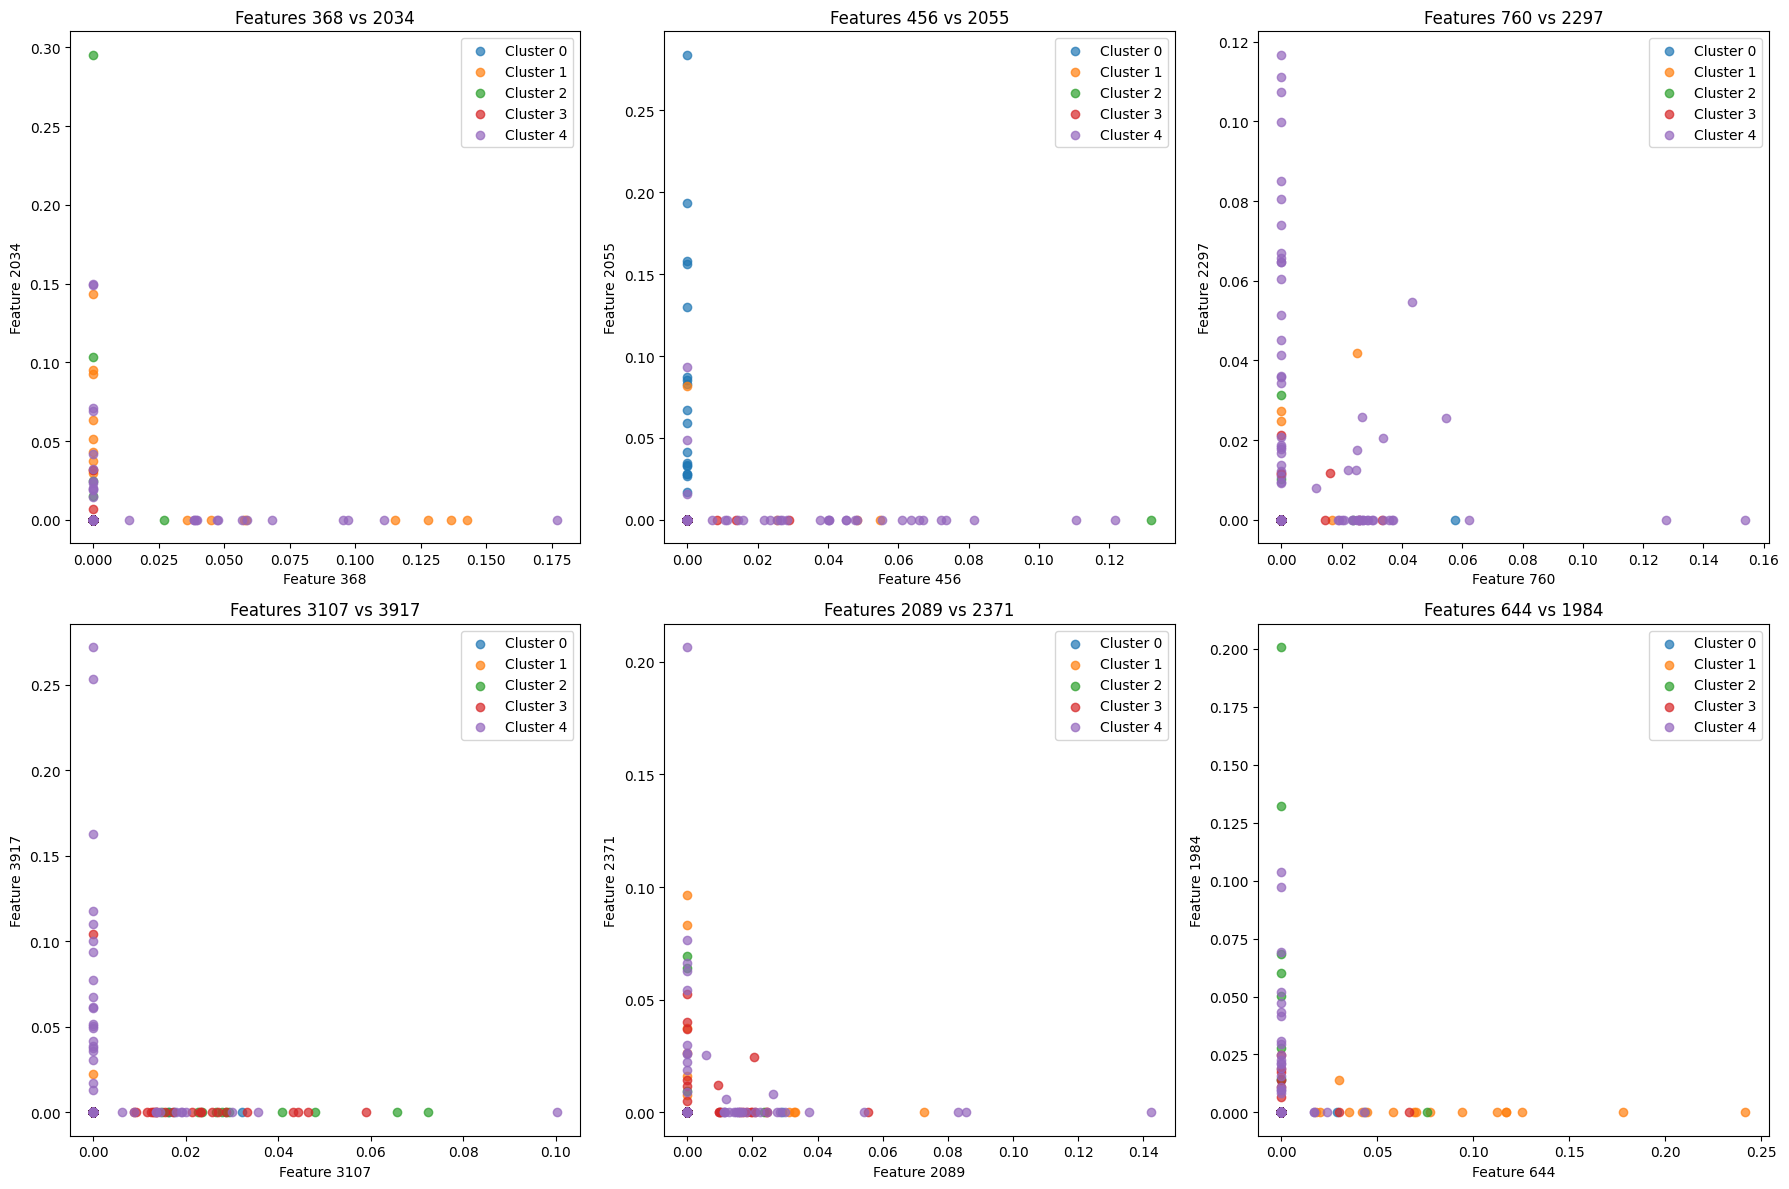

In [55]:
import matplotlib.pyplot as plt
import random

num_features = ratings.shape[1] - 1
num_pairs = 6

all_feature_pairs = [(i, j) for i in range(num_features) for j in range(i + 1, num_features)]

feature_pairs = random.sample(all_feature_pairs, num_pairs)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, (x_feature, y_feature) in enumerate(feature_pairs):
    ax = axes[i]

    for cluster_id in range(5):
        cluster_points = ratings[ratings['Cluster'] == cluster_id]
        ax.scatter(
            cluster_points.iloc[:, x_feature],
            cluster_points.iloc[:, y_feature],
            label=f'Cluster {cluster_id}',
            alpha=0.7
        )

    ax.set_title(f"Features {x_feature} vs {y_feature}")
    ax.set_xlabel(f"Feature {x_feature}")
    ax.set_ylabel(f"Feature {y_feature}")
    ax.legend()

plt.tight_layout()
plt.show()

Огромная размерность и чрезвычайная разреженность нашего признакового пространства не дает нам нормально выбрать два признака, по которым можно нормально разделить данные.

Для визуализации данных высокой размерности существует метод t-SNE (стохастическое вложение соседей с t-распределением). Данный метод является нелинейным методом снижения размерности: каждый объект высокой размерности будет моделироваться объектов более низкой (например, 2) размерности таким образом, чтобы похожие объекты моделировались близкими, непохожие - далекими с большой вероятностью.

Примените `TSNE` из библиотеки `sklearn` и визуализируйте полученные объекты, покрасив их в цвета их кластеров

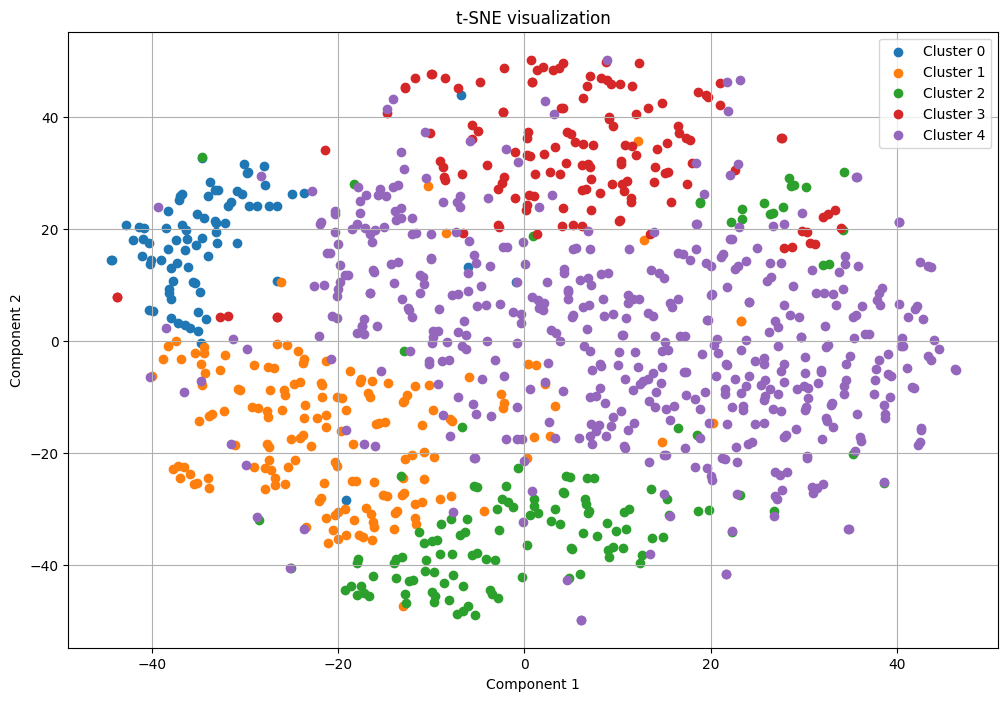

In [56]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
reduced_data = tsne.fit_transform(ratings.iloc[:, :-1])

reduced_df = pd.DataFrame(reduced_data, columns=['Component 1', 'Component 2'])
reduced_df['Cluster'] = cluster_labels

plt.figure(figsize=(12, 8))

for cluster_id in range(5):
  cluster_points = reduced_df[reduced_df['Cluster'] == cluster_id]
  plt.scatter(cluster_points['Component 1'], cluster_points['Component 2'],
              label=f'Cluster {cluster_id}')
plt.title("t-SNE visualization")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.legend()
plt.grid(True)
plt.show()

Такая визулизация позволяет четко увидеть границы классов и их различия по компонентам. Однако интерпретировать такие кластеры сложновато. Можно посмотреть степень их схожести и различия

## Задание 7 (1 балл) Подбор гиперпараметров

Подберите оптимальное количество кластеров (максимум 100 кластеров) с использованием индекса Силуэта. Зафиксируйте `random_state=42`

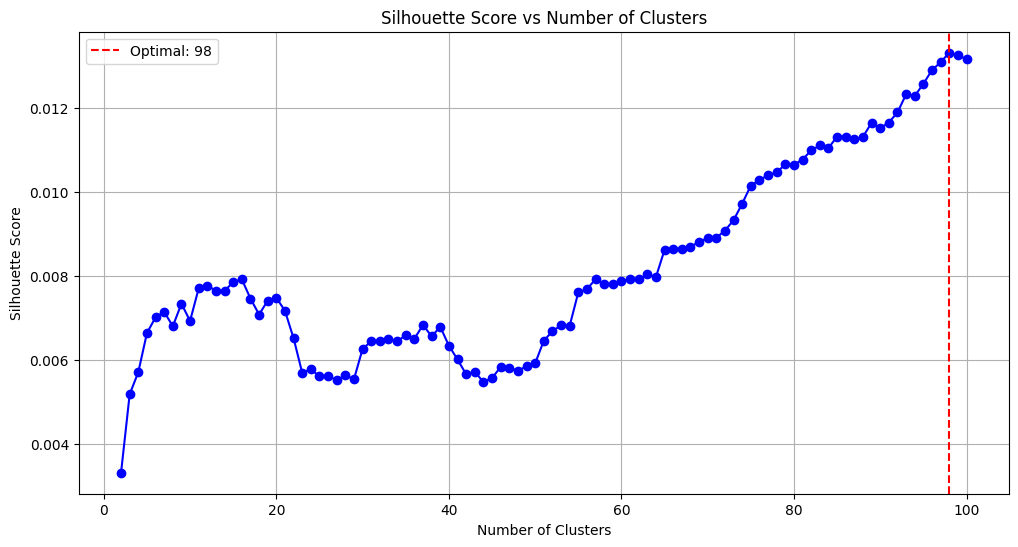


Оптимальное число кластеров: 98


In [57]:
from sklearn.metrics import silhouette_score
import numpy as np

range_n_clusters = range(2, 101)
silhouette_scores = []

for n_clusters in range_n_clusters:
  kmeans = KMeans(n_clusters=n_clusters, random_state=42)
  cluster_labels = kmeans.fit_predict(ratings.iloc[:, :-1])

  score = silhouette_score(ratings.iloc[:, :-1], cluster_labels)
  silhouette_scores.append(score)

optimal_n_clusters = range_n_clusters[np.argmax(silhouette_scores)]

plt.figure(figsize=(12, 6))
plt.plot(range_n_clusters, silhouette_scores, marker='o', linestyle='-', color='b')
plt.axvline(x=optimal_n_clusters, color='r', linestyle='--', label=f'Optimal: {optimal_n_clusters}')

plt.title("Silhouette Score vs Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.legend()
plt.grid(True)

plt.show()

print(f"\nОптимальное число кластеров: {optimal_n_clusters}")

Выведите исполнителей, ближайших с центроидам (аналогично заданию 5). Как соотносятся результаты? Остался ли смысл кластеров прежним? Расскажите про смысл 1-2 интересных кластеров, если он изменился и кластеров слишком много, чтобы рассказать про все.

In [59]:
#optimal_n_clusters = 5
kmeans = KMeans(n_clusters=optimal_n_clusters, random_state=42)
cluster_labels = kmeans.fit_predict(ratings.iloc[:, :-1])

ratings['Cluster'] = cluster_labels
centroids = kmeans.cluster_centers_

top_cluster_artists = {}

for cluster_id in range(optimal_n_clusters):
  centroid = centroids[cluster_id]
  distances = ratings.iloc[:, :-1].apply(lambda row: cosine(centroid, row), axis=1)
  top_artists = distances.nsmallest(10).index.tolist()
  top_cluster_artists[cluster_id] = top_artists

for cluster_id in range(min(5, optimal_n_clusters)):
    print(f"Кластер: {cluster_id}")
    print(top_cluster_artists[cluster_id])
    print()

Кластер: 0
['dr. dre', 'the faint', 'violent femmes', 'margot and the nuclear so and sos', 'owen', 'the bloodhound gang', 'cursive', 'van hallen', 'bright eyes', 'ironand wine']

Кластер: 1
['john mayer', 'matt nathanson', 'gavin degraw', 'jason mraz', 'ray lamontagne', 'joshua radin', 'sara bareilles', 'augustana', 'maroon5', 'o.a.r.']

Кластер: 2
['white stripes', 'beck', 'the raconteurs', 'spoon', 'the pixies', 'the strokes', 'the flaming lips', 'cake', 'black rebel motorcycle club', 'gorillaz']

Кластер: 3
['fugazi', 'jawbreaker', 'sleater-kinney', 'les savy fav', 'capn jazz', 'bad brains', 'blonde redhead', 'propagandhi', 'the melvins', 'gogol bordello']

Кластер: 4
['ryan adams', 'band of horses', 'ryan adams and the cardinals', 'rogue wave', 'my morning jacket', 'matt pond pa', 'cloud cult', 'the american analog set', 'nada surf', 'tv on the radio']



Теперь кластеры стали более узкими. Если раньше кластеры были более зонтичными, объединяя например весь рок, то теперь классы делятся на конкретные поджанры или отдельные стили

Сделайте t-SNE визуализацию полученной кластеризации.

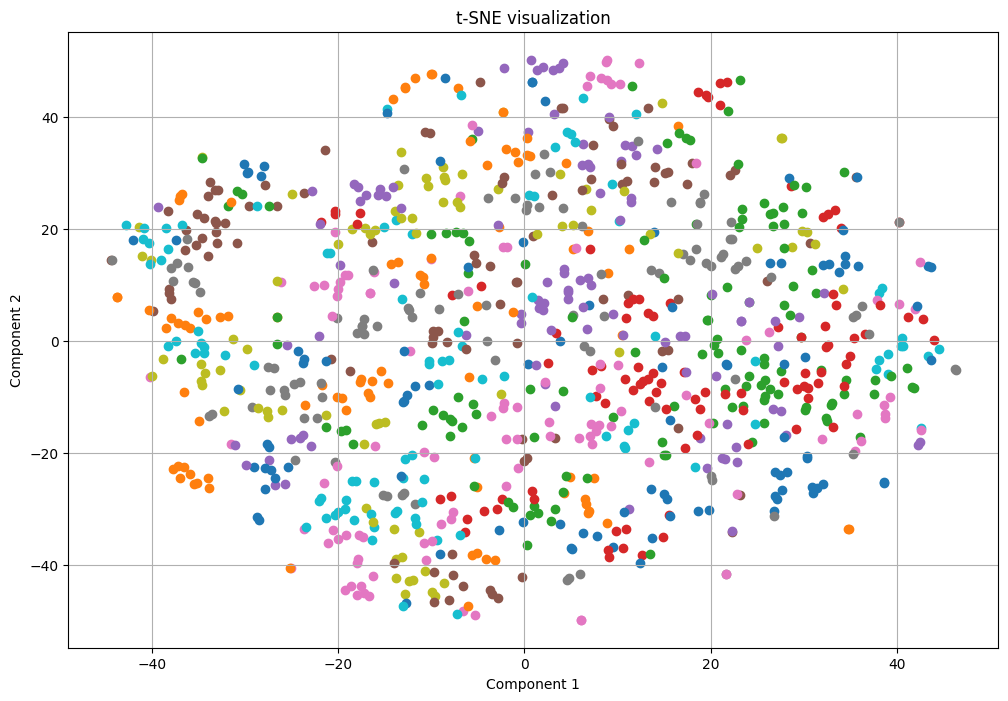

In [60]:
tsne = TSNE(n_components=2, random_state=42)
reduced_data = tsne.fit_transform(ratings.iloc[:, :-1])

reduced_df = pd.DataFrame(reduced_data, columns=['Component 1', 'Component 2'])
reduced_df['Cluster'] = cluster_labels

plt.figure(figsize=(12, 8))

for cluster_id in range(optimal_n_clusters):
  cluster_points = reduced_df[reduced_df['Cluster'] == cluster_id]
  plt.scatter(cluster_points['Component 1'], cluster_points['Component 2'],
              label=f'Cluster {cluster_id}')
plt.title("t-SNE visualization")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
#plt.legend()
plt.grid(True)
plt.show()

Если кластеров получилось слишком много и визуально цвета плохо отличаются, покрасьте только какой-нибудь интересный кластер из задания выше (`c = (labels == i)`). Хорошо ли этот кластер отражается в визуализации?

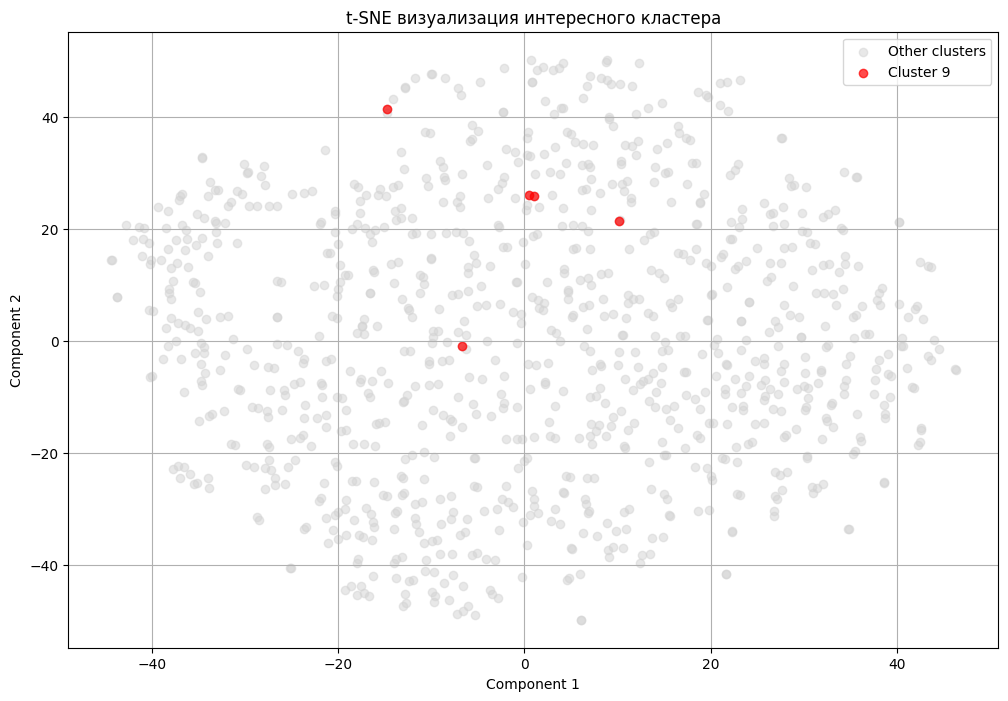

In [62]:
interesting_cluster = 9

plt.figure(figsize=(12, 8))

plt.scatter(
    reduced_df['Component 1'],
    reduced_df['Component 2'],
    c='lightgray',
    alpha=0.5,
    label='Other clusters'
)

cluster_points = reduced_df[reduced_df['Cluster'] == interesting_cluster]
plt.scatter(
    cluster_points['Component 1'],
    cluster_points['Component 2'],
    c='red',
    label=f'Cluster {interesting_cluster}',
    alpha=0.7
)

plt.title("t-SNE визуализация интересного кластера")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.legend()
plt.grid(True)

plt.show()

Теперь число кластеров слишком велико по сравнению с двумя измерениями t-SNE. Два измерения никак не позволяют адекватно разделить 98 кластеров, точки выглядят случайными